# Final test

One look at the test set, the newest vintages, kept untouched through every choice so
far. The tuned union configuration is refit on train and validation together, the whole book it
was selected on, and scored here once. Nothing is tuned to what follows.

What it does:

- Checks the model holds out of sample, ROC AUC, PR AUC, Brier and log-loss on the test set,
  against the tuned validation figures from notebook 24.
- Checks calibration still holds, since the pricing below trusts the probabilities to be honest,
  not only well ordered.
- Prices the decision in currency, the three policies from notebook 23 on realised test outcomes,
  to see whether that finding survives on data the model never saw.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

from credit_risk.data import load_loans, load_outcomes
from credit_risk.split import out_of_time_split
from credit_risk.model import (
    build_lgbm,
    UNDERWRITER_NUMERIC, UNDERWRITER_CATEGORICAL,
    LC_VERDICT_NUMERIC, LC_VERDICT_CATEGORICAL,
)
from credit_risk.evaluate import (
    discrimination_metrics,
    reliability_data,
    expected_profit,
    breakeven_probability,
)

TARGET = "target_bad"
NUMERIC = UNDERWRITER_NUMERIC + LC_VERDICT_NUMERIC
CATEGORICAL = UNDERWRITER_CATEGORICAL + LC_VERDICT_CATEGORICAL
COLS = NUMERIC + CATEGORICAL

df = load_loans()
train, val, test = out_of_time_split(df)
train_val = pd.concat([train, val])

# The tuned configuration, refit on everything before the test. n_estimators is inside best, so
# this is a plain fit with no early stopping.
best = json.loads((Path("..") / "reports" / "lgbm_best_params.json").read_text())
final = build_lgbm(NUMERIC, CATEGORICAL, params=best)
final.fit(train_val[COLS], train_val[TARGET])

test = test.assign(proba=final.predict_proba(test[COLS])[:, 1])
print(f"train+val {len(train_val)}, test {len(test)}, test bad rate {test[TARGET].mean():.3f}")

train+val 529915, test 178453, test bad rate 0.155


## Out of sample

The tuned model reached ROC AUC 0.699, PR AUC 0.279 and log-loss 0.392 on validation in notebook
24. That set helped select it, so those are a selection estimate. The test, never touched, is the
unbiased one. AUC is not comparable point for point across sets with different base rates, so read
it as whether the model held, not as a league table against validation.

In [2]:
metrics = discrimination_metrics(test[TARGET], test["proba"])
metrics["log_loss"] = log_loss(test[TARGET], test["proba"])
pd.Series(metrics).round(4)

roc_auc     0.7100
pr_auc      0.3034
brier       0.1214
log_loss    0.3950
dtype: float64

## Calibration

The pricing below multiplies by the predicted probability, so it only means something if that
probability is honest on the test set, not merely well ranked. The reliability curve checks it.

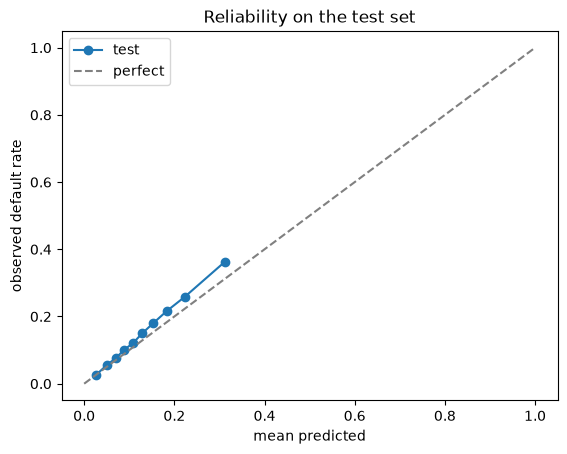

In [3]:
prob_true, prob_pred = reliability_data(test[TARGET], test["proba"])

plt.plot(prob_pred, prob_true, marker="o", label="test")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect")
plt.xlabel("mean predicted")
plt.ylabel("observed default rate")
plt.title("Reliability on the test set")
plt.legend()

out = Path("..") / "reports" / "reliability_test.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()

## What it is worth

The three policies from notebook 23, now on realised test outcomes. The single break-even
threshold is set on train and validation, the book the final model was trained on, so it never
sees the test either. The question is whether notebook 23's finding holds on unseen data: does one
threshold still keep pace with per-loan pricing, and does the approve-or-reject decision still add
little?

In [4]:
outcomes = load_outcomes().drop(columns=["loan_amnt"])
scored = test.merge(outcomes, on="id")
assert len(scored) == len(test)

scored["realised_profit"] = (
    scored["total_rec_prncp"] + scored["recoveries"] + scored["total_rec_int"] - scored["loan_amnt"]
)
scored["exp_profit"] = expected_profit(scored["proba"], scored["loan_amnt"], scored["int_rate"])

# Threshold from train+val, the book the model was trained on, never from the test.
r_bar = (train_val["int_rate"] * train_val["loan_amnt"]).sum() / train_val["loan_amnt"].sum()
c = breakeven_probability(r_bar)
print(f"single break-even: {c:.3f}, from an average rate of {r_bar:.1f}%")

policies = {
    "approve all": pd.Series(True, index=scored.index),
    "single break-even": scored["proba"] < c,
    "expected profit": scored["exp_profit"] > 0,
}

rows = {}
for name, approve in policies.items():
    taken = scored[approve]
    rows[name] = {
        "approved": len(taken),
        "total_profit": taken["realised_profit"].sum(),
        "profit_per_loan": taken["realised_profit"].mean(),
        "bad_rate": taken[TARGET].mean(),
    }

pd.DataFrame(rows).T

single break-even: 0.310, from an average rate of 12.0%


,approved,total_profit,profit_per_loan,bad_rate
approve all,178453.0,1.249339e+08,700.094229,0.154640
single break-even,171292.0,1.298791e+08,758.232385,0.143422
expected profit,177203.0,1.265340e+08,714.062585,0.152582


## Conclusions

The ranking held out of sample. ROC AUC came in at 0.710 and PR AUC at 0.303, both a little above
the tuned validation figures, so the model orders risk on vintages it never saw at least as well
as validation suggested. With a higher base rate on the test that is held rather than improved,
but it is not a degradation.

Calibration slipped. The reliability curve underpredicts across the range, a 0.36 default rate
observed where it priced 0.31, a 0.22 where it priced 0.18. The newest vintage defaulted more than
the ones it trained on, a 0.155 test bad rate, and a model fit on older data does not fully see it.
Brier and log-loss come in a touch worse than validation for the same reason. The probabilities
are still honest enough to price with, but they lean low.

That slippage decides the money. The single break-even earns 129.9M, ahead of per-loan pricing at
126.5M and approving everything at 124.9M. Notebook 23's finding not only survives, it widens: the
gap between the single threshold and per-loan pricing grows to 3.4M, from under 1M on validation.
The reason is the underprediction. Per-loan pricing trusts the probability right up to each loan's
break-even, so on a vintage where the probabilities lean low it approves 6027 high-rate loans that
default at 41% and lose 3.4M. The single threshold is coarser and never reaches for them, which
makes it the more robust rule exactly when calibration drifts.

So the model generalises in what it is for, ranking, and the decision layer's simplest rule is
also its safest. The caveats stand: the book is only Lending Club's approved loans, and the
economics assume no discounting and past recovery behaviour. On this book the approve-or-reject
decision is worth a few percent at most, and one threshold set on the training book captures it.